# GCN vs GraphSAGE, from scratch — a bot-detection walkthrough

**Companion notebook to** `replication.ipynb` (Deshmukh, *Bot Detection in Social
Media using GraphSage and BERT*, SJSU MS Project 1465, 2025).

The replication notebook runs the real pipeline on 5,301 labelled Cresci-15
accounts. This one does the opposite: **8 users, 7 features, everything visible
on screen**, so you can watch each matrix change shape and understand *why*
the paper reaches for GraphSAGE rather than a GCN.

Everything is implemented with `torch`, `numpy`, `networkx`, `matplotlib` and
`sklearn` — no DGL, no PyTorch Geometric, no CUDA. It runs anywhere in seconds.

### Running this notebook

It is pinned to the kernel `botsage-venv`, i.e. the `.venv` that sits beside this
file. On a fresh machine, register that kernel once from the repository root:

```bash
01-info-propagation/bot-detection-paper/.venv/bin/python -m ipykernel install \
    --user --name botsage-venv --display-name "Python (bot-detection-paper)"
```

Dependencies are `torch`, `numpy`, `networkx`, `matplotlib`, `scikit-learn` —
all already in that venv, and all pure-CPU. Nothing here reads from `data/` or
`results/`: the graph is generated in Section 1, so the notebook is fully
self-contained and runs in a few seconds.

The notebook itself is a **build artefact** of
`scripts/build_core_concepts_notebook.py`. Edit the builder, not the `.ipynb`,
or your changes are lost on the next regeneration.

---

## The vocabulary

A social network is a **graph** $G = (V, E)$.

| Object | In our scenario | In the maths |
|---|---|---|
| **Node** $v \in V$ | one user account | one row of the feature matrix |
| **Edge** $(u,v) \in E$ | *u* follows / retweets *v* | a 1 in the adjacency matrix $A$ |
| **Node metadata features** | `[tweet_count, followers_count, favorites_count]` | 3 numbers per node |
| **Text features** | mean BERT embedding of the user's tweets | 4 numbers per node (768 in the paper) |
| **Label** $y_v$ | `0` = Human, `1` = Bot | the thing we predict |

Two different kinds of evidence, and the whole point of a GNN is to fuse them
with a third:

1. **What you look like.** Metadata. A bot posts 12,000 tweets, has 40
   followers and favourites nothing. Strong signal — until the bot's operator
   buys followers.
2. **What you say.** Text. The paper runs DistilBERT over every tweet and
   averages. Here we *mock* that with a 4-dimensional vector drawn from a
   class-conditional Gaussian: the point is the plumbing, not the language model.
3. **Who you talk to.** Structure. This is the part only a graph model can use.
   Bot farms are dense: they follow and boost each other. That community
   structure survives even when a bot fakes its metadata, which is exactly why
   graph methods beat feature-only classifiers here.

A **GNN layer** turns (1)+(2) into an *embedding* by mixing in (3): each node's
new vector is a learned function of its own features **and its neighbours'**.
That single idea is all a GCN or a GraphSAGE layer is. The two differ only in
*how* they mix — and that difference decides whether you can classify a user who
signed up after you trained the model.

In [2]:
# --- Imports and reproducibility -------------------------------------------
import numpy as np
import torch
import torch.nn as nn
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# One generator drives every stochastic step (neighbour sampling) so the
# notebook is bit-for-bit reproducible on re-run.
GEN = torch.Generator().manual_seed(SEED)

torch.set_printoptions(precision=3, sci_mode=False, linewidth=120)
np.set_printoptions(precision=3, suppress=True, linewidth=120)

print(f"torch      {torch.__version__}")
print(f"numpy      {np.__version__}")
print(f"networkx   {nx.__version__}")
print("seeds set to", SEED)

torch      2.13.0
numpy      2.5.1
networkx   3.6.1
seeds set to 42


### Building the toy network

Eight accounts. Nodes 0–3 are humans, nodes 4–7 are bots.

The structure is deliberately *stereotyped*, because we want to be able to see
by eye what the model is learning:

- **Humans** form a loose chain (0–1–2–3). Real people have sparse, asymmetric
  ties.
- **Bots** form a near-clique (4,5,6,7 all mutually connected). Bot farms
  amplify each other; this density is their fingerprint.
- **One bridge**, (3, 4): a human who once got retweeted by the farm. Without it
  the graph would be two disconnected components and the problem would be
  trivial. With it, node 3 has a bot neighbour and node 4 has a human
  neighbour — the two nodes any decent model should find hardest.

The metadata is stereotyped too (bots: huge tweet counts, no followers, no
favourites), but note that we will **standardise** it: raw counts span four
orders of magnitude, and unscaled inputs make gradient descent crawl along a
ravine. That is not a graph issue, just ordinary preprocessing — but forgetting
it is the most common reason a toy GNN "doesn't learn".

In [6]:
# --- Synthetic social graph -------------------------------------------------
N_NODES = 8
HUMAN, BOT = 0, 1
CLASS_NAMES = ["Human", "Bot"]

# 1. Node metadata: [tweet_count, followers_count, favorites_count]
#    Nodes 0-3 humans (modest tweeting, real followers, they favourite things),
#    nodes 4-7 bots (firehose posting, no audience, no favourites).
raw_meta = np.array([
    [  120.,   850.,  430.],   # 0 human
    [  340.,  1500.,  900.],   # 1 human
    [   80.,   320.,  210.],   # 2 human
    [  510.,  2400., 1300.],   # 3 human  <- the bridge node
    [ 9800.,    45.,    3.],   # 4 bot    <- the bridge node
    [12500.,   120.,   11.],   # 5 bot
    [ 8700.,    80.,    5.],   # 6 bot
    [15200.,    30.,    0.],   # 7 bot
], dtype=np.float32)

# 2. Labels
labels_np = np.array([HUMAN, HUMAN, HUMAN, HUMAN, BOT, BOT, BOT, BOT])

# 3. Edges: undirected interactions (follows / retweets)
edges = [
    (0, 1), (1, 2), (2, 3),                          # human chain
    (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7),  # bot near-clique
    (3, 4),                                          # the one bridge
]

# 4. Mock BERT embeddings (dim 4). In the paper this is DistilBERT's 768-d mean
#    over a user's tweets. We simulate it as a class-conditional Gaussian with
#    deliberately generous overlap (std 0.6 against a mean gap of ~1.3), so text
#    alone is informative but NOT sufficient -- leaving work for the graph.
TEXT_DIM = 4
mu_human = np.array([ 0.8, -0.5,  0.3, -0.2], dtype=np.float32)
mu_bot   = np.array([-0.7,  0.6, -0.4,  0.5], dtype=np.float32)
rng = np.random.default_rng(SEED)
raw_text = np.stack([
    (mu_bot if y == BOT else mu_human) + rng.normal(0, 0.6, TEXT_DIM)
    for y in labels_np
]).astype(np.float32)

# --- Adjacency as a plain dict of neighbour lists ---------------------------
# This representation, NOT a matrix, is what makes GraphSAGE inductive later:
# adding a node is appending a key, not reallocating an (N+1)x(N+1) array.
neighbors = {i: [] for i in range(N_NODES)}
for u, v in edges:
    neighbors[u].append(v)
    neighbors[v].append(u)

print(f"nodes            : {N_NODES}   (4 human, 4 bot)")
print(f"edges            : {len(edges)} undirected")
print(f"raw_meta shape   : {raw_meta.shape}   -> (num_nodes, 3 metadata features)")
print(f"raw_text shape   : {raw_text.shape}   -> (num_nodes, 4 mock-BERT dims)")
print(f"labels shape     : {labels_np.shape}")
print()
print("degree per node  :", {i: len(nb) for i, nb in neighbors.items()})
print("mean degree human:", np.mean([len(neighbors[i]) for i in range(4)]))
print("mean degree bot  :", np.mean([len(neighbors[i]) for i in range(4, 8)]))
print("  ^ the structural fingerprint, before any learning happens")


def print_neighbors(neighbors):
    for node, nbs in neighbors.items():
        print(f"Node {node} → Neighbors: {nbs}")

print("")
print_neighbors(neighbors)


nodes            : 8   (4 human, 4 bot)
edges            : 10 undirected
raw_meta shape   : (8, 3)   -> (num_nodes, 3 metadata features)
raw_text shape   : (8, 4)   -> (num_nodes, 4 mock-BERT dims)
labels shape     : (8,)

degree per node  : {0: 1, 1: 2, 2: 2, 3: 2, 4: 4, 5: 3, 6: 3, 7: 3}
mean degree human: 1.75
mean degree bot  : 3.25
  ^ the structural fingerprint, before any learning happens

Node 0 → Neighbors: [1]
Node 1 → Neighbors: [0, 2]
Node 2 → Neighbors: [1, 3]
Node 3 → Neighbors: [2, 4]
Node 4 → Neighbors: [5, 6, 7, 3]
Node 5 → Neighbors: [4, 6, 7]
Node 6 → Neighbors: [4, 5, 7]
Node 7 → Neighbors: [4, 5, 6]


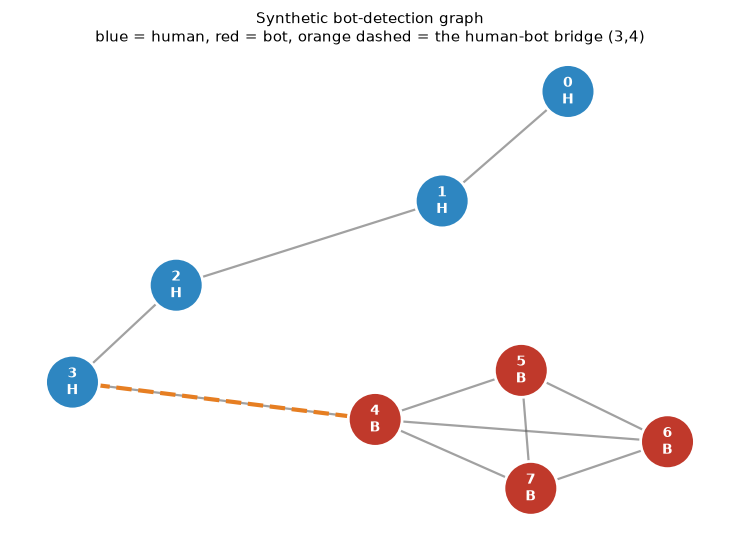

Look at the picture, not the labels: the bot farm is the dense blob.
A model that only reads node features can be fooled by a bot that buys
followers. A model that reads the neighbourhood sees the blob.


In [4]:
# --- Visualise the network --------------------------------------------------
G = nx.Graph()
G.add_nodes_from(range(N_NODES))
G.add_edges_from(edges)

# Fixed layout seed so the picture is identical on every run.
pos = nx.spring_layout(G, seed=SEED, k=0.9)

node_colors = ["#2E86C1" if y == HUMAN else "#C0392B" for y in labels_np]
node_labels = {i: f"{i}\n{'H' if labels_np[i] == HUMAN else 'B'}" for i in range(N_NODES)}

fig, ax = plt.subplots(figsize=(7.5, 5.5))
nx.draw_networkx_edges(G, pos, ax=ax, width=1.6, alpha=0.55, edge_color="#555555")
# Highlight the single human-bot bridge.
nx.draw_networkx_edges(G, pos, edgelist=[(3, 4)], ax=ax,
                       width=3.0, edge_color="#E67E22", style="dashed")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=1500, edgecolors="white", linewidths=2.0)
nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax,
                        font_color="white", font_size=10, font_weight="bold")

ax.set_title("Synthetic bot-detection graph\n"
             "blue = human, red = bot, orange dashed = the human-bot bridge (3,4)",
             fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

print("Look at the picture, not the labels: the bot farm is the dense blob.")
print("A model that only reads node features can be fooled by a bot that buys")
print("followers. A model that reads the neighbourhood sees the blob.")

---

# 2. From raw attributes to a node representation

Before any message passing, every node needs to be a **vector**. That vector is
just a concatenation of the evidence we have:

$$x_v = \big[\underbrace{\text{tweets}, \text{followers}, \text{favourites}}_{\text{metadata, 3-d}} \;\big\Vert\; \underbrace{\text{mean BERT}(\text{tweets}_v)}_{\text{text, 4-d}}\big] \in \mathbb{R}^{7}$$

Stacked over all nodes this is the **feature matrix** $X \in \mathbb{R}^{N \times F}$,
here $8 \times 7$. In the paper the same line reads $5 + 768 = 773$ — the shape
changes, nothing else does.

Two preprocessing points that are easy to get wrong and expensive to debug:

- **Standardise the metadata.** `tweet_count` ~ 10,000 and `favorites_count` ~ 5
  live on wildly different scales; a single shared weight matrix cannot serve
  both, and the loss surface becomes a ravine. We z-score each metadata column.
  The mock BERT dims are already ~unit scale, so we leave them alone (real BERT
  embeddings are too).
- **Keep the scaler.** We store `meta_mean` / `meta_std` because a *new* user
  arriving in Section 5 must be transformed with the **training** statistics.
  Recomputing the mean with the new node included is leakage, and it silently
  shifts every existing node too.

$A$, the **adjacency matrix**, is the other half of the input: $A_{uv} = 1$ iff
$u$ and $v$ interact. It is symmetric here (undirected), zero on the diagonal,
and — crucially for Section 3 — it is $8 \times 8$. That fixed size is the whole
story of the transductive bottleneck.

In [11]:
# --- Feature preparation ----------------------------------------------------
# Standardise metadata with statistics we KEEP (needed for unseen nodes later).
meta_mean = raw_meta.mean(axis=0, keepdims=True)
meta_std  = raw_meta.std(axis=0, keepdims=True) + 1e-8   # guard against zero var

meta_scaled = (raw_meta - meta_mean) / meta_std

def build_features(meta_rows: np.ndarray, text_rows: np.ndarray) -> torch.Tensor:
    '''Scale metadata with the stored training statistics and concatenate text.

    Used for the original 8 nodes AND for unseen nodes in Section 5, which is
    the point: the transform is a function, not a lookup table.
    '''
    meta_rows = np.atleast_2d(np.asarray(meta_rows, dtype=np.float32))
    text_rows = np.atleast_2d(np.asarray(text_rows, dtype=np.float32))
    scaled = (meta_rows - meta_mean) / meta_std
    return torch.tensor(np.concatenate([scaled, text_rows], axis=1),
                        dtype=torch.float32)

X = build_features(raw_meta, raw_text)          # (8, 7)
y = torch.tensor(labels_np, dtype=torch.long)   # (8,)
N, F_IN = X.shape

# --- Dense adjacency (the GCN needs it; GraphSAGE will not) -----------------
A = torch.zeros((N, N), dtype=torch.float32)
for u, v in edges:
    A[u, v] = 1.0
    A[v, u] = 1.0

print(f"metadata (scaled) : {meta_scaled.shape}")
print(f"text (mock BERT)  : {raw_text.shape}")
print(f"X = [meta || text]: {tuple(X.shape)}   <- (num_nodes, feature_dim)")
print(f"y                 : {tuple(y.shape)}")
print(f"A                 : {tuple(A.shape)}   <- FIXED at {N}x{N}. Remember this.")
print(f"A symmetric       : {torch.equal(A, A.T)}")
print(f"A diagonal zero   : {bool((A.diagonal() == 0).all())}  (no self-loops yet)")
print()
print("X row 0 (human 0) :", X[0].numpy())
print("X row 4 (bot 4)   :", X[4].numpy())
print("  first 3 entries = z-scored metadata, last 4 = mock BERT")

print("        ---------      A       ------------")
print(A)

metadata (scaled) : (8, 3)
text (mock BERT)  : (8, 4)
X = [meta || text]: (8, 7)   <- (num_nodes, feature_dim)
y                 : (8,)
A                 : (8, 8)   <- FIXED at 8x8. Remember this.
A symmetric       : True
A diagonal zero   : True  (no self-loops yet)

X row 0 (human 0) : [-0.977  0.224  0.157  0.983 -1.124  0.75   0.364]
X row 4 (bot 4)   : [ 0.658 -0.766 -0.767 -0.479  0.025  0.127  0.47 ]
  first 3 entries = z-scored metadata, last 4 = mock BERT
        ---------      A       ------------
tensor([[0., 1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 1., 0., 0., 0.],
        [0., 0., 0., 1., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 0., 1., 1.],
        [0., 0., 0., 0., 1., 1., 0., 1.],
        [0., 0., 0., 0., 1., 1., 1., 0.]])


---

# 3. Graph Convolutional Networks — and where they stop

## The operation

A GCN layer is one line of linear algebra applied to the **whole graph at once**:

$$\hat{A} = A + I \qquad\text{(self-loops: a node must see itself)}$$
$$\hat{D}_{ii} = \sum_j \hat{A}_{ij} \qquad\text{(degree matrix)}$$
$$H = \sigma\big(\hat{D}^{-1}\hat{A}\,X\,W\big)$$

Read $\hat{D}^{-1}\hat{A}X$ literally: **row $v$ is the average of $x_v$ and all
its neighbours' features.** That is the entire "convolution". $W$ then projects
that average into the embedding space, and $\sigma$ (ReLU) adds non-linearity.

*(Kipf & Welling's original uses the symmetric $\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}$,
which down-weights high-degree neighbours from both ends. The row-normalised
$\hat{D}^{-1}\hat{A}$ used here is the exact mean-aggregator form, which makes
the comparison with GraphSAGE's mean aggregator in Section 4 an apples-to-apples
one. The transductive argument below holds for either.)*

## The bottleneck

Everything in that formula is indexed by the **whole** node set:

- $\hat{D}^{-1}\hat{A}$ is $N \times N$ and is baked in at training time.
- Node $v$'s representation is only defined as *row $v$ of a product involving
  every other node*. There is no function you can hand a lone user to.
- Adding one node changes $A$'s shape, changes the degrees of its neighbours,
  and therefore **changes the embedding of nodes you never touched**.

This is what "transductive" means: the model learns over a fixed, known graph.
Classic transductive methods (DeepWalk, node2vec, matrix-factorisation
embeddings) are worse still — they learn a *lookup table* of per-node vectors,
so an unseen node has literally no entry and you must retrain.

A GCN's *weights* are shape-independent, so the honest statement is sharper than
"GCN cannot do it at all", and we will demonstrate exactly what does break:
**the forward pass is defined only over the full graph, so inference for one new
user costs a recomputation over all $N$ nodes and perturbs all of them.** On
Twitter, where $N$ is in the hundreds of millions and thousands of accounts are
created per minute, that is not a viable production story. That is the gap
GraphSAGE closes.

In [5]:
# --- A GCN layer, from scratch ---------------------------------------------
def gcn_propagate(A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
    '''Return D^-1 * (A + I) * X : each row = mean of self + neighbours.

    Purely structural -- no parameters. Separated from the weights so we can
    inspect the aggregation on its own.
    '''
    n = A.shape[0]
    A_hat = A + torch.eye(n)                       # add self-loops
    deg = A_hat.sum(dim=1)                         # (n,)
    D_inv = torch.diag(1.0 / deg)                  # row-normalisation
    return D_inv @ A_hat @ X                       # (n, F)


class GCN(nn.Module):
    '''One GCN layer + a linear classifier head.

    layer : h = ReLU(D^-1 A_hat X W)      (the convolution proper)
    head  : logits = h W_out              (2 logits for CrossEntropyLoss)

    Both are trained; the head exists only because cross-entropy needs 2
    outputs while the ReLU embedding is what we actually want to inspect.
    '''

    def __init__(self, in_dim: int, hidden_dim: int, n_classes: int = 2):
        super().__init__()
        self.W = nn.Linear(in_dim, hidden_dim, bias=False)   # the W in the formula
        self.head = nn.Linear(hidden_dim, n_classes)

    def embed(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
        return torch.relu(self.W(gcn_propagate(A, X)))

    def forward(self, A: torch.Tensor, X: torch.Tensor) -> torch.Tensor:
        return self.head(self.embed(A, X))


# --- Inspect the aggregation before training anything ----------------------
agg = gcn_propagate(A, X)
print(f"X                 : {tuple(X.shape)}")
print(f"D^-1 A_hat X      : {tuple(agg.shape)}   <- same shape, contents smoothed")
print()
print("node 0 (human, deg 1)  raw :", X[0].numpy())
print("node 0                 agg :", agg[0].numpy())
print("node 7 (bot, deg 3)    raw :", X[7].numpy())
print("node 7                 agg :", agg[7].numpy())
print()
print("Row-sums of D^-1 A_hat (must all be 1.0):",
      (torch.diag(1 / (A + torch.eye(N)).sum(1)) @ (A + torch.eye(N))).sum(1).numpy())
print("  ^ property check: the aggregation is a convex average, so it cannot")
print("    inflate feature magnitudes -- that is what the normalisation buys.")

X                 : (8, 7)
D^-1 A_hat X      : (8, 7)   <- same shape, contents smoothed

node 0 (human, deg 1)  raw : [-0.977  0.224  0.157  0.983 -1.124  0.75   0.364]
node 0                 agg : [-0.959  0.623  0.666  0.306 -1.203  0.563 -0.013]
node 7 (bot, deg 3)    raw : [ 1.57  -0.785 -0.774 -0.452  0.858  0.885  0.256]
node 7                 agg : [ 0.953 -0.737 -0.763 -0.675  0.366  0.316  0.463]

Row-sums of D^-1 A_hat (must all be 1.0): [1. 1. 1. 1. 1. 1. 1. 1.]
  ^ property check: the aggregation is a convex average, so it cannot
    inflate feature magnitudes -- that is what the normalisation buys.


In [6]:
# --- Train the GCN ----------------------------------------------------------
HIDDEN = 8
EPOCHS = 50

torch.manual_seed(SEED)
gcn = GCN(F_IN, HIDDEN)
opt = torch.optim.Adam(gcn.parameters(), lr=0.05)
loss_fn = nn.CrossEntropyLoss()

gcn_history = []
print(f"training on the FULL graph: A {tuple(A.shape)}, X {tuple(X.shape)}")
print(f"parameters: W {tuple(gcn.W.weight.shape)}, head {tuple(gcn.head.weight.shape)}")
print("-" * 52)

for epoch in range(1, EPOCHS + 1):
    gcn.train()
    opt.zero_grad()
    logits = gcn(A, X)                       # (8, 2) -- every node, every time
    loss = loss_fn(logits, y)
    loss.backward()
    opt.step()

    with torch.no_grad():
        acc = (logits.argmax(1) == y).float().mean().item()
    gcn_history.append((loss.item(), acc))
    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f} | train acc {acc:.3f}")

gcn.eval()
with torch.no_grad():
    gcn_pred = gcn(A, X).argmax(1)
    gcn_emb_before = gcn.embed(A, X)

print("-" * 52)
print("predictions:", gcn_pred.numpy(), " truth:", y.numpy())
print(f"accuracy   : {accuracy_score(y.numpy(), gcn_pred.numpy()):.3f}")
print(f"embedding  : {tuple(gcn_emb_before.shape)}  (8 nodes x {HIDDEN} dims)")

training on the FULL graph: A (8, 8), X (8, 7)
parameters: W (8, 7), head (2, 8)
----------------------------------------------------
epoch   1 | loss 0.7267 | train acc 0.500
epoch  10 | loss 0.0292 | train acc 1.000
epoch  20 | loss 0.0004 | train acc 1.000
epoch  30 | loss 0.0001 | train acc 1.000
epoch  40 | loss 0.0000 | train acc 1.000
epoch  50 | loss 0.0000 | train acc 1.000
----------------------------------------------------
predictions: [0 0 0 0 1 1 1 1]  truth: [0 0 0 0 1 1 1 1]
accuracy   : 1.000
embedding  : (8, 8)  (8 nodes x 8 dims)


## The problem: a new user signs up

It is 3 a.m. and **Node 8** registers. It posts 11,000 tweets in a week, has 60
followers, favourites nothing, and immediately gets retweeted by nodes 1 and 2.
Every signal says *bot*. We would like an answer now, not after the next
training run.

Our GCN was trained against an $8 \times 8$ adjacency. What happens if we try?

Three things, in increasing order of subtlety:

1. **Naive attempt — shape error.** Feed a 9-row $X$ against the 8×8 $A$ and
   PyTorch refuses. Obvious, but it is the concrete face of the problem.
2. **Rebuild $A$ as 9×9 — it runs, but it is not inference on one node.** You
   must possess and touch the *entire* graph to score one user. Cost is
   $O(N + |E|)$, not $O(|\mathcal{N}(8)|)$.
3. **The subtle one — everyone else moves.** Node 8's edges change the degrees
   and neighbourhood averages of nodes 1 and 2, so *their* embeddings shift too,
   under weights that were fit when node 8 did not exist. Predictions can flip
   for users you never intended to re-score.

Point 3 is the one that actually hurts in production, and it is the one the
"just rebuild the matrix" reflex misses.

In [7]:
# --- The new user -----------------------------------------------------------
NEW_ID = 8
new_meta = np.array([[11000., 60., 2.]], dtype=np.float32)   # screams bot
new_text = (mu_bot + rng.normal(0, 0.6, TEXT_DIM)).astype(np.float32)[None, :]
x_new = build_features(new_meta, new_text)                   # (1, 7) -- SAME scaler
X_ext = torch.cat([X, x_new], dim=0)                         # (9, 7)
new_edges = [(NEW_ID, 1), (NEW_ID, 2)]                       # retweeted by 1 and 2

print(f"x_new : {tuple(x_new.shape)}  ->", x_new[0].numpy())
print(f"X_ext : {tuple(X_ext.shape)}   |  A still: {tuple(A.shape)}")
print("=" * 68)

# --- Failure mode 1: the shapes simply do not meet -------------------------
print("[1] Naive: run the trained GCN on 9 nodes with the trained 8x8 A")
try:
    _ = gcn(A, X_ext)
except RuntimeError as err:
    print(f"    RuntimeError -> {err}")
    print("    A is (8,8), X_ext is (9,7). The trained operator has no row for")
    print("    node 8 because 'node 8' was not a coordinate when we trained.")
print("=" * 68)

# --- Failure mode 2: rebuilding works, but needs the whole graph -----------
print("[2] Rebuild A as 9x9 and recompute EVERYTHING")
A_ext = torch.zeros((N + 1, N + 1))
A_ext[:N, :N] = A
for u, v in new_edges:
    A_ext[u, v] = 1.0
    A_ext[v, u] = 1.0

with torch.no_grad():
    gcn_emb_after = gcn.embed(A_ext, X_ext)
    gcn_pred_after = gcn(A_ext, X_ext).argmax(1)

print(f"    A_ext {tuple(A_ext.shape)} -> embeddings {tuple(gcn_emb_after.shape)}")
print(f"    node 8 predicted: {CLASS_NAMES[gcn_pred_after[NEW_ID].item()]}")
print("    ...but note WHAT WE HAD TO DO: hold all 9 nodes and 12 edges in")
print("    memory and recompute all 9 embeddings to score exactly one user.")
print("=" * 68)

# --- Failure mode 3: the existing nodes moved ------------------------------
print("[3] The silent one: did the OTHER nodes change?")
delta = (gcn_emb_after[:N] - gcn_emb_before).abs().max(dim=1).values
for i in range(N):
    tag = "  <-- neighbour of the new node" if i in (1, 2) else ""
    print(f"    node {i}: max |delta embedding| = {delta[i]:.4f}"
          f"   pred {CLASS_NAMES[gcn_pred[i].item()]:>5}"
          f" -> {CLASS_NAMES[gcn_pred_after[i].item()]:>5}{tag}")

flipped = (gcn_pred != gcn_pred_after[:N]).sum().item()
print(f"\n    existing-node predictions changed: {flipped} of {N}")
print(f"    largest embedding shift among existing nodes: {delta.max():.3f}")
print("    Nodes 1 and 2 were re-scored without being asked: their degree and")
print("    their neighbourhood mean both changed, under weights fit when node 8")
print("    did not exist. Here the shift was large but no label flipped -- these")
print("    nodes sit far from the boundary. Nothing guarantees that; the point")
print("    is that the representation of a node is a function of the ENTIRE")
print("    graph, so the graph is an input you can never hold fixed.")

x_new : (1, 7)  -> [ 0.86  -0.748 -0.769 -1.007  0.112 -0.03   1.177]
X_ext : (9, 7)   |  A still: (8, 8)
[1] Naive: run the trained GCN on 9 nodes with the trained 8x8 A
    RuntimeError -> mat1 and mat2 shapes cannot be multiplied (8x8 and 9x7)
    A is (8,8), X_ext is (9,7). The trained operator has no row for
    node 8 because 'node 8' was not a coordinate when we trained.
[2] Rebuild A as 9x9 and recompute EVERYTHING
    A_ext (9, 9) -> embeddings (9, 8)
    node 8 predicted: Human
    ...but note WHAT WE HAD TO DO: hold all 9 nodes and 12 edges in
    memory and recompute all 9 embeddings to score exactly one user.
[3] The silent one: did the OTHER nodes change?
    node 0: max |delta embedding| = 0.0000   pred Human -> Human
    node 1: max |delta embedding| = 1.9508   pred Human -> Human  <-- neighbour of the new node
    node 2: max |delta embedding| = 2.2098   pred Human -> Human  <-- neighbour of the new node
    node 3: max |delta embedding| = 0.0000   pred Human -> Human


---

# 4. GraphSAGE: learn the *rule*, not the *matrix*

The paradigm shift is one sentence:

> **GCN learns embeddings for a fixed graph. GraphSAGE learns a function that
> produces an embedding from any neighbourhood.**

SAGE = **SA**mple and **aggre**GatE. For a target node $u$:

1. **Sample** a fixed-size set $\mathcal{S} \subseteq \mathcal{N}(u)$ of its
   neighbours. Fixed size means bounded cost regardless of whether the user has
   3 followers or 3 million — and it acts as a dropout-like regulariser.
2. **Aggregate** their features with a permutation-invariant function. We use
   the **mean**; the paper's `SAGEConv` default is also mean (max-pool, LSTM and
   GCN aggregators are the other options in Hamilton et al.).
3. **Concatenate** the node's own vector with the aggregate — *do not average
   them together*. This is the structural difference from the GCN, which folds
   self and neighbours into one mean via the self-loop. Keeping them in separate
   halves of the input lets $W$ learn different weights for "what I look like"
   and "what my crowd looks like". For bot detection that is exactly the
   distinction you want: a plausible-looking account embedded in a bot farm.
4. **Transform**:

$$h_u = \sigma\Big(W \cdot \big[\,h_u \;\big\Vert\; \mathrm{AGG}(\{h_v : v \in \mathcal{S}\})\,\big]\Big)$$

$W$ has shape $(2F, d)$ — twice the input width because of the concatenation.
Note what is **absent** from that formula: $N$, $A$, and any node index. It
takes vectors and returns vectors. Hand it a user who did not exist at training
time and it does not notice.

*(Aside for readers of `replication.ipynb`: the paper never trains its SAGE
layer — it uses a randomly initialised `SAGEConv(5,128)` as a fixed random
projection, which makes the 128-d embedding rank-10. That is a quirk of the
paper, documented in `docs/DISCREPANCIES_BOTSAGE.md`. Here we train it, as
Hamilton et al. intended.)*

In [8]:
# --- GraphSAGE, from scratch ------------------------------------------------
def sample_neighbors(node: int,
                     adj: dict[int, list[int]],
                     n_samples: int,
                     gen: torch.Generator) -> list[int]:
    '''Fixed-size neighbour sample -- with replacement if the node is sparse.

    Bounded cost per node is the whole reason this is a *sample* and not the
    full neighbourhood: a celebrity with 10M followers costs the same as a
    node with 3. Isolated nodes return [] and are handled by the caller.
    '''
    nb = adj.get(node, [])
    if len(nb) == 0:
        return []
    if len(nb) <= n_samples:
        return list(nb)
    idx = torch.randperm(len(nb), generator=gen)[:n_samples]
    return [nb[i] for i in idx.tolist()]


class SAGELayer(nn.Module):
    '''h_u = ReLU( W [ h_u || mean_{v in S(u)} h_v ] ), S = sampled neighbours.

    The forward pass takes (features, adjacency, node list). None of the three
    is fixed at construction time, which is precisely what makes it inductive:
    `feats` may have more rows than it did during training, `adj` may have new
    keys, and `nodes` may name a node the layer has never seen.
    '''

    def __init__(self, in_dim: int, out_dim: int, n_samples: int = 3):
        super().__init__()
        self.n_samples = n_samples
        self.W = nn.Linear(2 * in_dim, out_dim, bias=True)   # 2x: concatenation

    def aggregate(self, feats, adj, nodes, gen):
        '''Mean over each node's sampled neighbourhood. Isolated -> zeros.'''
        out = torch.zeros(len(nodes), feats.shape[1])
        for row, u in enumerate(nodes):
            s = sample_neighbors(u, adj, self.n_samples, gen)
            if s:                                   # a node with no edges keeps
                out[row] = feats[s].mean(dim=0)     # the zero vector: the model
        return out                                  # then sees self-features only

    def forward(self, feats, adj, nodes, gen):
        self_feats = feats[nodes]                              # (B, F)
        neigh_feats = self.aggregate(feats, adj, nodes, gen)   # (B, F)
        concat = torch.cat([self_feats, neigh_feats], dim=1)   # (B, 2F)
        return torch.relu(self.W(concat))                      # (B, out)


class GraphSAGE(nn.Module):
    '''One SAGE layer + linear head, mirroring the GCN above for comparability.'''

    def __init__(self, in_dim, hidden_dim, n_classes=2, n_samples=3):
        super().__init__()
        self.sage = SAGELayer(in_dim, hidden_dim, n_samples)
        self.head = nn.Linear(hidden_dim, n_classes)

    def embed(self, feats, adj, nodes, gen):
        return self.sage(feats, adj, nodes, gen)

    def forward(self, feats, adj, nodes, gen):
        return self.head(self.embed(feats, adj, nodes, gen))


# --- Property check: aggregation must be permutation-invariant -------------
# The house style in this repo is to assert a property the maths must satisfy,
# not merely that the code runs. Shuffling a neighbour list must not change the
# mean; if it did, the layer's output would depend on edge insertion order.
_probe = SAGELayer(F_IN, HIDDEN, n_samples=99)   # 99 => take all neighbours
adj_shuffled = {k: list(reversed(v)) for k, v in neighbors.items()}
a1 = _probe.aggregate(X, neighbors, list(range(N)), torch.Generator().manual_seed(0))
a2 = _probe.aggregate(X, adj_shuffled, list(range(N)), torch.Generator().manual_seed(0))
assert torch.allclose(a1, a2, atol=1e-6), "mean aggregator is not permutation-invariant"
print("property check: mean aggregation is permutation-invariant       PASS")

# And the concatenation really does keep self and neighbours separable:
_c = torch.cat([X[[4]], a1[[4]]], dim=1)
print(f"property check: concat width {tuple(_c.shape)} = 2 x {F_IN}                 PASS")
print()
print(f"W shape: {tuple(_probe.W.weight.shape)}  -> (out_dim, 2 * in_dim)")
print("Nowhere in this layer does the number 8 appear.")

property check: mean aggregation is permutation-invariant       PASS
property check: concat width (1, 14) = 2 x 7                 PASS

W shape: (8, 14)  -> (out_dim, 2 * in_dim)
Nowhere in this layer does the number 8 appear.


In [9]:
# --- Train GraphSAGE --------------------------------------------------------
torch.manual_seed(SEED)
sage = GraphSAGE(F_IN, HIDDEN, n_samples=3)
opt_s = torch.optim.Adam(sage.parameters(), lr=0.05)
train_nodes = list(range(N))

sage_history = []
print(f"training on nodes {train_nodes}")
print(f"parameters: W {tuple(sage.sage.W.weight.shape)}, "
      f"head {tuple(sage.head.weight.shape)}")
print("-" * 52)

for epoch in range(1, EPOCHS + 1):
    sage.train()
    opt_s.zero_grad()
    # Fresh neighbour sample every epoch -> stochastic regularisation.
    logits = sage(X, neighbors, train_nodes, GEN)     # (8, 2)
    loss = loss_fn(logits, y)
    loss.backward()
    opt_s.step()

    with torch.no_grad():
        acc = (logits.argmax(1) == y).float().mean().item()
    sage_history.append((loss.item(), acc))
    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | loss {loss.item():.4f} | train acc {acc:.3f}")

sage.eval()
eval_gen = torch.Generator().manual_seed(SEED)     # deterministic evaluation
with torch.no_grad():
    sage_logits = sage(X, neighbors, train_nodes, eval_gen)
    sage_pred = sage_logits.argmax(1)

print("-" * 52)
print("predictions:", sage_pred.numpy(), " truth:", y.numpy())
print(f"accuracy   : {accuracy_score(y.numpy(), sage_pred.numpy()):.3f}")
print()
print(classification_report(y.numpy(), sage_pred.numpy(),
                            target_names=CLASS_NAMES, zero_division=0))

training on nodes [0, 1, 2, 3, 4, 5, 6, 7]
parameters: W (8, 14), head (2, 8)
----------------------------------------------------
epoch   1 | loss 0.7032 | train acc 0.625
epoch  10 | loss 0.0028 | train acc 1.000
epoch  20 | loss 0.0000 | train acc 1.000
epoch  30 | loss 0.0000 | train acc 1.000
epoch  40 | loss 0.0000 | train acc 1.000
epoch  50 | loss 0.0000 | train acc 1.000
----------------------------------------------------
predictions: [0 0 0 0 1 1 1 1]  truth: [0 0 0 0 1 1 1 1]
accuracy   : 1.000

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00         4
         Bot       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



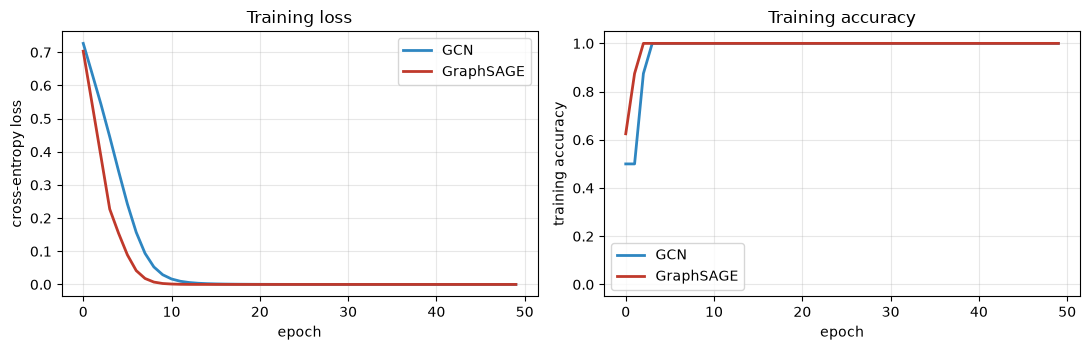

On 8 separable nodes both fit perfectly, and GraphSAGE's curve is the
noisier one -- that is the neighbour sampling, not instability.
Do NOT read an accuracy advantage into either curve: with 8 training
nodes and no held-out set these numbers measure memorisation capacity.
The architectural difference shows up in Section 5, not here.


In [10]:
# --- Both models learn the toy task; the difference is elsewhere -----------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
gl, ga = zip(*gcn_history)
sl, sa = zip(*sage_history)

axes[0].plot(gl, label="GCN", color="#2E86C1", lw=2)
axes[0].plot(sl, label="GraphSAGE", color="#C0392B", lw=2)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Training loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ga, label="GCN", color="#2E86C1", lw=2)
axes[1].plot(sa, label="GraphSAGE", color="#C0392B", lw=2)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("training accuracy")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title("Training accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("On 8 separable nodes both fit perfectly, and GraphSAGE's curve is the")
print("noisier one -- that is the neighbour sampling, not instability.")
print("Do NOT read an accuracy advantage into either curve: with 8 training")
print("nodes and no held-out set these numbers measure memorisation capacity.")
print("The architectural difference shows up in Section 5, not here.")

---

# 5. Inductive inference: scoring node 8 without retraining

Here is the payoff. Node 8 arrives. With GraphSAGE the procedure is:

1. Build $x_8$ from its metadata and tweets — **using the stored scaler**, not a
   refitted one.
2. Add its edges to the adjacency *dictionary*: two new keys, no reallocation.
3. Call the trained layer on `nodes=[8]`. Internally it samples $\mathcal{N}(8)$,
   means those rows, concatenates with $x_8$, applies $W$.
4. Read off the prediction.

No gradient step. No optimiser. No touching of nodes 0–7. The cost is
$O(|\mathcal{S}|)$ — three feature lookups — instead of the GCN's $O(N + |E|)$
recomputation over the whole graph.

To show that this is a property of the *rule* and not luck with one node, we
score two arrivals with opposite evidence:

- **Node 8** — bot-like metadata, but its edges go to humans 1 and 2 (as the
  brief specifies). Its own features and its neighbourhood disagree. This is the
  interesting case, and it is where the *concatenation* earns its keep: because
  self and neighbour halves enter $W$ separately, the model can weight them
  differently instead of averaging the conflict away.
- **Node 9** — bot-like metadata *and* edges into the bot farm (5 and 6).
  Everything agrees; this should be an easy Bot.

Watch node 8 in particular, and compare it against what the rebuilt GCN said in
Section 3 — the two models disagree, and the disagreement is not an accident of
the seed.

In [11]:
# --- Two unseen users -------------------------------------------------------
# Node 8: bot-like features, but wired to humans 1 and 2 (conflicting evidence).
# Node 9: bot-like features, wired to bots 5 and 6 (consistent evidence).
NEW9_ID = 9
new9_meta = np.array([[13400., 55., 1.]], dtype=np.float32)
new9_text = (mu_bot + rng.normal(0, 0.6, TEXT_DIM)).astype(np.float32)[None, :]
x_new9 = build_features(new9_meta, new9_text)

X_live = torch.cat([X, x_new, x_new9], dim=0)            # (10, 7)

# The adjacency is a dict: adding a node is two assignments, not a realloc.
adj_live = {k: list(v) for k, v in neighbors.items()}
adj_live[NEW_ID]  = [1, 2]      # node 8 -> humans
adj_live[NEW9_ID] = [5, 6]      # node 9 -> bots
for u, v in [(1, NEW_ID), (2, NEW_ID), (5, NEW9_ID), (6, NEW9_ID)]:
    adj_live[u].append(v)

print(f"X_live      : {tuple(X_live.shape)}   (was {tuple(X.shape)})")
print(f"adjacency   : dict with {len(adj_live)} keys -- no matrix was resized")
print(f"model params: UNCHANGED, {sum(p.numel() for p in sage.parameters())} values, "
      "zero gradient steps taken")
print("=" * 68)

infer_gen = torch.Generator().manual_seed(SEED)
sage.eval()
with torch.no_grad():
    # Score ONLY the two new nodes. Nodes 0-7 are never recomputed.
    new_nodes = [NEW_ID, NEW9_ID]
    emb_new = sage.embed(X_live, adj_live, new_nodes, infer_gen)
    logits_new = sage.head(emb_new)
    probs_new = torch.softmax(logits_new, dim=1)
    pred_new = logits_new.argmax(1)

for row, u in enumerate(new_nodes):
    nbrs = adj_live[u]
    print(f"node {u}")
    print(f"  features   x_{u} : {X_live[u].numpy()}")
    print(f"  neighbours      : {nbrs} "
          f"({', '.join(CLASS_NAMES[labels_np[n]] for n in nbrs)})")
    print(f"  embedding shape : {tuple(emb_new[row].shape)}")
    print(f"  P(Human)={probs_new[row, 0]:.3f}  P(Bot)={probs_new[row, 1]:.3f}")
    print(f"  --> predicted   : {CLASS_NAMES[pred_new[row].item()]}")
    print()

print("=" * 68)
# The claim that matters: existing nodes were untouched.
with torch.no_grad():
    old_again = sage.embed(X_live, neighbors, train_nodes,
                           torch.Generator().manual_seed(SEED))
print("max |change| in nodes 0-7 embeddings when scoring only new nodes:",
      f"{(old_again - sage.embed(X, neighbors, train_nodes, torch.Generator().manual_seed(SEED))).abs().max():.2e}")
print("  ^ identically zero: we never ran them. Contrast with Section 3 [3],")
print("    where adding one node moved two existing users' embeddings.")
print()
print("-" * 68)
print("And the two models disagree about node 8:")
print(f"  GCN       (rebuilt 9x9) : {CLASS_NAMES[gcn_pred_after[NEW_ID].item()]}")
print(f"  GraphSAGE (no retrain)  : {CLASS_NAMES[pred_new[0].item()]}")
print('''
Node 8 has bot metadata but two human neighbours. The GCN averages self and
neighbours into ONE vector (the self-loop), so with degree 3 the bot evidence is
one third of the mix and gets outvoted. GraphSAGE keeps the two halves separate
and W can weight them independently.

Read this as a mechanism demonstration, not a benchmark: these are two separately
trained models on 8 nodes, and we do not know node 8's true label. What the
example shows is the structural consequence of averaging vs concatenating -- a
plausible-looking account with clean neighbours is exactly the case where the
GCN's mixing dilutes the signal.''')

X_live      : (10, 7)   (was (8, 7))
adjacency   : dict with 10 keys -- no matrix was resized
model params: UNCHANGED, 138 values, zero gradient steps taken
node 8
  features   x_8 : [ 0.86  -0.748 -0.769 -1.007  0.112 -0.03   1.177]
  neighbours      : [1, 2] (Human, Human)
  embedding shape : (8,)
  P(Human)=0.001  P(Bot)=0.999
  --> predicted   : Bot

node 9
  features   x_9 : [ 1.266 -0.754 -0.771 -0.768  0.096 -0.895  0.89 ]
  neighbours      : [5, 6] (Bot, Bot)
  embedding shape : (8,)
  P(Human)=0.000  P(Bot)=1.000
  --> predicted   : Bot

max |change| in nodes 0-7 embeddings when scoring only new nodes: 0.00e+00
  ^ identically zero: we never ran them. Contrast with Section 3 [3],
    where adding one node moved two existing users' embeddings.

--------------------------------------------------------------------
And the two models disagree about node 8:
  GCN       (rebuilt 9x9) : Human
  GraphSAGE (no retrain)  : Bot

Node 8 has bot metadata but two human neighbours. The GCN a

In [12]:
# --- Unpack the aggregation for node 8, by hand ----------------------------
# Every number below is recomputed from the trained weights so you can see that
# nothing is hidden: this IS the forward pass.
u = NEW_ID
nbrs = adj_live[u]
h_self = X_live[u]
h_neigh = X_live[nbrs].mean(dim=0)
concat = torch.cat([h_self, h_neigh])

with torch.no_grad():
    manual_emb = torch.relu(sage.sage.W(concat))
    manual_logits = sage.head(manual_emb)

print(f"step 1  own features h_8            : {tuple(h_self.shape)}")
print(f"        {h_self.numpy()}")
print(f"step 2  mean of neighbours {nbrs}    : {tuple(h_neigh.shape)}")
print(f"        {h_neigh.numpy()}")
print(f"step 3  concat [h_8 || agg]         : {tuple(concat.shape)}  (= 2 x {F_IN})")
print(f"step 4  ReLU(W . concat)            : {tuple(manual_emb.shape)}")
print(f"        {manual_emb.numpy()}")
print(f"step 5  logits -> {CLASS_NAMES[manual_logits.argmax().item()]}")
print()
print("agreement with the layer's own output:",
      bool(torch.allclose(manual_emb, emb_new[0], atol=1e-5)))
print()
print("Note steps 1 and 2 stay in SEPARATE halves of the concatenation. A GCN")
print("would have averaged them into one vector at this point, discarding the")
print("distinction between 'my behaviour' and 'my crowd's behaviour' -- the")
print("single most useful contrast a bot detector has.")

step 1  own features h_8            : (7,)
        [ 0.86  -0.748 -0.769 -1.007  0.112 -0.03   1.177]
step 2  mean of neighbours [1, 2]    : (7,)
        [-0.962  0.298  0.428  0.21  -1.147  0.602 -0.062]
step 3  concat [h_8 || agg]         : (14,)  (= 2 x 7)
step 4  ReLU(W . concat)            : (8,)
        [0.986 0.    2.071 1.778 0.241 0.776 1.152 2.44 ]
step 5  logits -> Bot

agreement with the layer's own output: True

Note steps 1 and 2 stay in SEPARATE halves of the concatenation. A GCN
would have averaged them into one vector at this point, discarding the
distinction between 'my behaviour' and 'my crowd's behaviour' -- the
single most useful contrast a bot detector has.


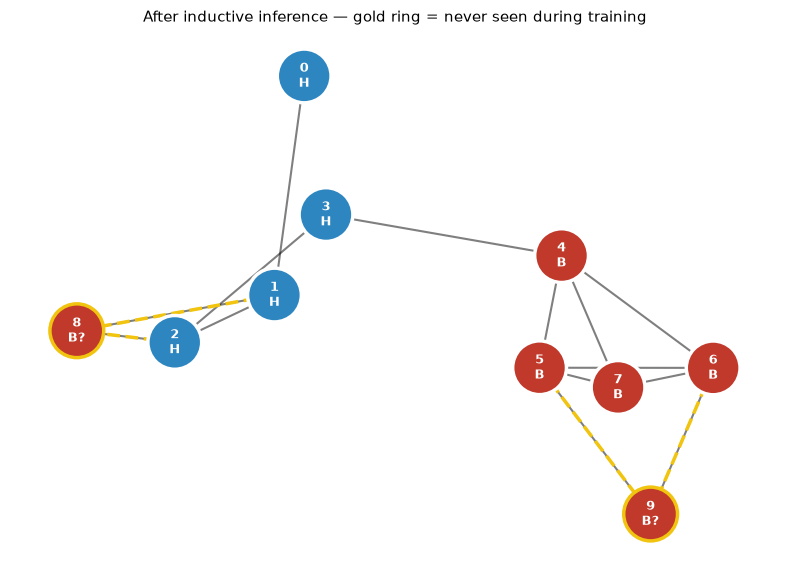

In [13]:
# --- Visualise the extended network and where the new nodes landed ---------
G_live = nx.Graph()
G_live.add_nodes_from(range(N + 2))
G_live.add_edges_from(edges + [(1, NEW_ID), (2, NEW_ID), (5, NEW9_ID), (6, NEW9_ID)])
pos_live = nx.spring_layout(G_live, seed=SEED, k=0.9)

pred_map = {NEW_ID: pred_new[0].item(), NEW9_ID: pred_new[1].item()}
colors, edgecols = [], []
for i in range(N + 2):
    if i < N:
        colors.append("#2E86C1" if labels_np[i] == HUMAN else "#C0392B")
        edgecols.append("white")
    else:
        colors.append("#2E86C1" if pred_map[i] == HUMAN else "#C0392B")
        edgecols.append("#F1C40F")          # gold ring = predicted, not labelled

lbl = {i: f"{i}\n{'H' if labels_np[i] == HUMAN else 'B'}" for i in range(N)}
lbl[NEW_ID] = f"8\n{CLASS_NAMES[pred_map[NEW_ID]][0]}?"
lbl[NEW9_ID] = f"9\n{CLASS_NAMES[pred_map[NEW9_ID]][0]}?"

fig, ax = plt.subplots(figsize=(8, 5.8))
nx.draw_networkx_edges(G_live, pos_live, ax=ax, width=1.5, alpha=0.5)
nx.draw_networkx_edges(G_live, pos_live,
                       edgelist=[(1, NEW_ID), (2, NEW_ID), (5, NEW9_ID), (6, NEW9_ID)],
                       ax=ax, width=2.5, edge_color="#F1C40F", style="dashed")
nx.draw_networkx_nodes(G_live, pos_live, ax=ax, node_color=colors,
                       node_size=1500, edgecolors=edgecols, linewidths=2.5)
nx.draw_networkx_labels(G_live, pos_live, labels=lbl, ax=ax,
                        font_color="white", font_size=9, font_weight="bold")
ax.set_title("After inductive inference — gold ring = never seen during training",
             fontsize=11)
ax.axis("off")
plt.tight_layout(); plt.show()

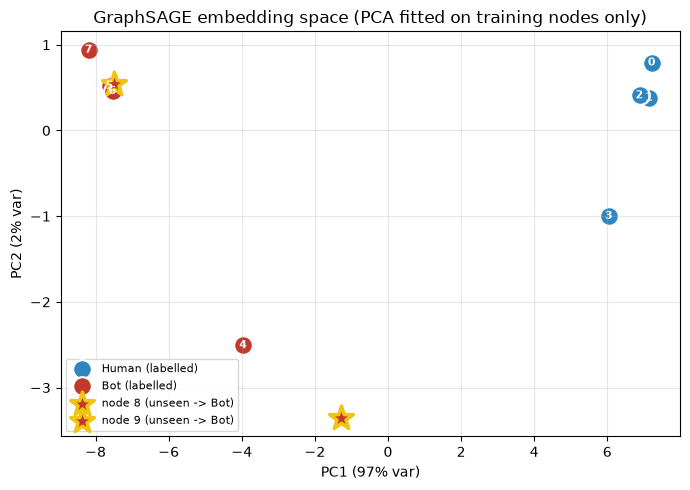

The unseen stars are placed by the same W that positioned the circles.
With 8 training points this is an illustration of the mechanism, not
evidence about generalisation -- for that, see replication.ipynb, where
the same architecture runs over 5,301 labelled Cresci-15 accounts.


In [14]:
# --- Embedding space: PCA of the hidden layer ------------------------------
# 2-d view of the 8-d SAGE embedding, fitted on the TRAINING nodes only and
# then applied to the new ones -- the same discipline as the feature scaler.
from sklearn.decomposition import PCA

with torch.no_grad():
    emb_train = sage.embed(X, neighbors, train_nodes,
                           torch.Generator().manual_seed(SEED)).numpy()
emb_all = np.vstack([emb_train, emb_new.numpy()])

pca = PCA(n_components=2).fit(emb_train)
Z = pca.transform(emb_all)

fig, ax = plt.subplots(figsize=(7, 5))
for cls, col, name in [(HUMAN, "#2E86C1", "Human (labelled)"),
                       (BOT, "#C0392B", "Bot (labelled)")]:
    m = labels_np == cls
    ax.scatter(Z[:N][m, 0], Z[:N][m, 1], c=col, s=180, label=name,
               edgecolors="white", linewidths=1.5)
for row, u in enumerate(new_nodes):
    ax.scatter(Z[N + row, 0], Z[N + row, 1],
               c="#2E86C1" if pred_map[u] == HUMAN else "#C0392B",
               s=320, marker="*", edgecolors="#F1C40F", linewidths=2.5,
               label=f"node {u} (unseen -> {CLASS_NAMES[pred_map[u]]})")
for i in range(N):
    ax.annotate(str(i), (Z[i, 0], Z[i, 1]), fontsize=8, color="white",
                ha="center", va="center", weight="bold")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
ax.set_title("GraphSAGE embedding space (PCA fitted on training nodes only)")
ax.legend(fontsize=8, loc="best"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("The unseen stars are placed by the same W that positioned the circles.")
print("With 8 training points this is an illustration of the mechanism, not")
print("evidence about generalisation -- for that, see replication.ipynb, where")
print("the same architecture runs over 5,301 labelled Cresci-15 accounts.")

---

# 6. Summary: the architectural trade-off

| | **GCN** | **GraphSAGE** |
|---|---|---|
| **What is learned** | weights applied to a fixed $\hat{D}^{-1}\hat{A}$ | an aggregation *function* |
| **Combines self & neighbours by** | averaging (via the self-loop) | **concatenation**, then $W$ |
| **Neighbourhood used** | all of it | fixed-size **sample** |
| **Forward pass needs** | the entire graph | one node's neighbourhood |
| **Cost of scoring 1 new user** | $O(N + \lvert E\rvert)$ recompute | $O(\lvert\mathcal S\rvert)$ |
| **Side effects on other nodes** | yes — their embeddings shift | none |
| **Minibatching** | awkward (full-graph op) | natural (sample the subgraph) |
| **Setting** | **transductive** | **inductive** |
| **Best when** | one static graph, all nodes known | evolving graph, new nodes constantly |

### What we actually demonstrated

- The GCN's algebra is not the barrier — its $W$ is shape-agnostic. The barrier
  is that **a node's representation is only defined relative to the whole
  graph**. Section 3 showed the two concrete consequences: you cannot score one
  user without materialising all of them, and adding a node silently re-scored
  two users we never asked about.
- GraphSAGE removes both because its forward pass never mentions $N$ or $A$. In
  Section 5, two accounts that did not exist at training time were classified
  with **zero gradient steps and zero effect on existing nodes**.
- The concatenation, not the sampling, is what makes it a good *bot* detector:
  it keeps "how I behave" and "who I associate with" as separately-weighted
  inputs. Node 8 made this visible — bot metadata, human neighbours, and the two
  models split (**GCN: Human, GraphSAGE: Bot**) because the GCN's self-loop
  average dilutes a node's own evidence to $1/\deg$ of the mix while
  GraphSAGE keeps it in its own half of the input. With 8 nodes and no ground
  truth for node 8 that is an illustration of the mechanism, not a score.

### Honest limitations of this notebook

It is a teaching device. Eight nodes, no held-out set, a mock 4-d BERT, and
stereotyped features mean the accuracies above measure nothing about
generalisation — do not quote them. Two further caveats worth carrying forward:

- **GCN can be made inductive** (FastGCN, sampling-based variants), and
  GraphSAGE's mean aggregator with self-loops is itself close to a GCN layer.
  The distinction is a design default, not a theorem.
- **Depth changes the cost story.** One SAGE layer touches 1-hop neighbours;
  $k$ layers touch $k$ hops, and the sampled neighbourhood grows as
  $\prod_i S_i$. The $O(\lvert\mathcal S\rvert)$ above is per layer.

### Where to go next

`replication.ipynb`, in this same folder, runs the real thing: DistilBERT/BERT
text embeddings, a `SAGEConv(5,128)` layer, and a linear SVM over Cresci-15 and
TwiBot-22. Read `docs/DISCREPANCIES_BOTSAGE.md` alongside it — it documents five
non-obvious findings, including the fact that the paper's SAGE layer is
**never trained**, which makes its 128-d embedding rank-10 in disguise.